![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Segmentación de Clientes con Clustering Jerárquico y DBSCAN

El objetivo de este caso-taller es analizar una base de datos ficticia sobre clientes de una tienda y buscar encontrar grupos de clientes que permitan generar estrategias de marketing focalizadas. La base se encuentra en los `Archivos de Laboratorio` en la carpeta `data` y cuenta con 200 observaciones y 5 variables:

- `Id_Cliente`: identificador de cliente.
- `Genero`: género del cliente: Mujer, Hombre
- `Edad`: edad en años
- `Ingreso`: ingresos anuales
- `Puntaje_Gasto`: es una variable que mide cuán a menudo un cliente compra en la tienda, siendo 100 el puntaje más alto.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

En la carpeta `data` se encuentra el archivo `datos_clientes.csv` cargue estos datos en su *cuaderno*.

In [9]:
#Estandarización de ambiente y configuración general
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance_matrix
from sklearn.datasets import make_blobs
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import fcluster


#Cargamos la base de datos
url = "https://raw.githubusercontent.com/camto-24/Taller-2-Aprendizaje-no-supervisado/refs/heads/main/data/datos_clientes.csv"
data = pd.read_csv(url)

#Revisamos las primeras filas
data.head()
data.shape

(200, 5)

Para iniciar el análisis, se configuró el entorno de trabajo incorporando las librerías necesarias para manipulación de datos, visualización y técnicas de clustering. Posteriormente, dado que el archivo no se encontraba de forma local en el entorno de ejecución de Google Colab, se procedió a importar la base de datos directamente desde el repositorio alojado en GitHub mediante su enlace en formato raw. Finalmente, se verificó la correcta carga del conjunto de datos, asegurando la disponibilidad de las 200 observaciones y 5 variables requeridas para el desarrollo del ejercicio.

### 2. Análisis preliminar.

Antes de comenzar el análisis de segmentación utilice estadísticas descriptivas para explorar la variables que se encuentran en los datos. En su análisis mencione si hay patrones que surgen del examen descriptivo de los datos; entre ellos si hay diferencias en los ingresos y los puntajes de gastos para mujeres y hombres, por grupos etarios (18-24, 25-34, 35-44, 45-54, 55-64, y 65+), y por grupos etarios y género. Discuta además si estas diferencias son estadísticamente significativas.

/tmp/ipykernel_3555/3625055906.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Grupo_Edad")[["Ingreso", "Puntaje_Gasto"]].mean()


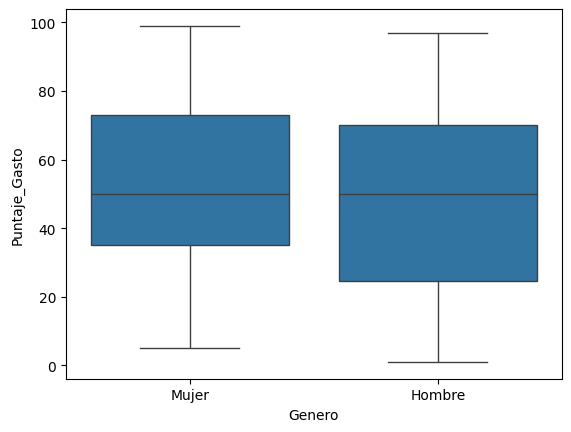

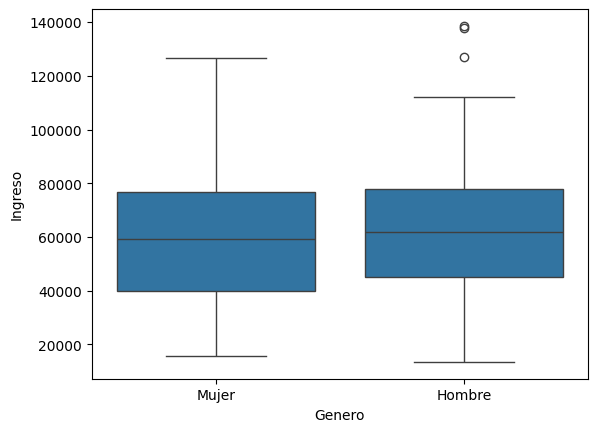

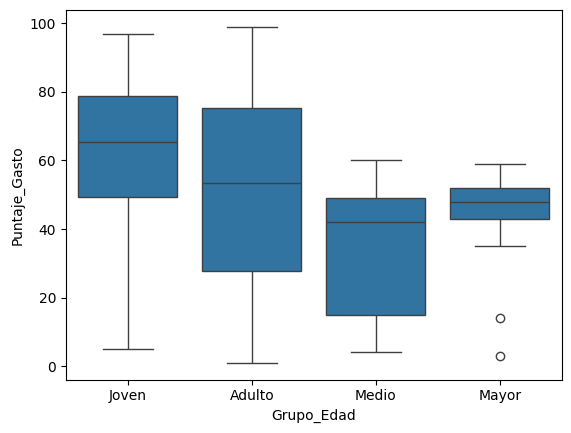

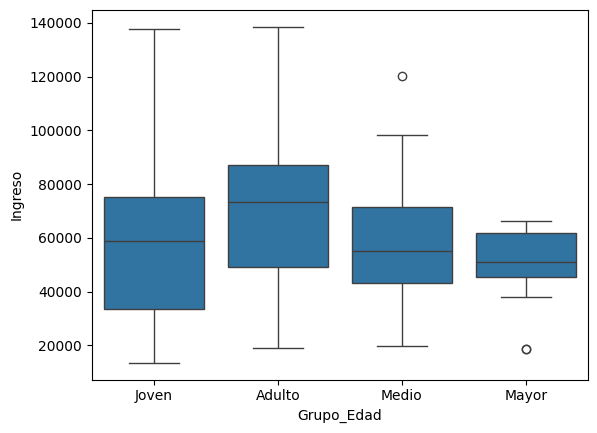

In [10]:
# Estadísticas generales
data.describe()

#Exploración de la base
data.columns

#Agrupación por género
data.groupby("Genero")[["Ingreso", "Puntaje_Gasto"]].mean()

#Agrupación por edad
data["Grupo_Edad"] = pd.cut(data["Edad"],
                         bins=[18,30,45,60,100],
                         labels=["Joven","Adulto","Medio","Mayor"])

data.groupby("Grupo_Edad")[["Ingreso", "Puntaje_Gasto"]].mean()


#Visualizamos género vs gasto
sns.boxplot(x="Genero", y="Puntaje_Gasto", data=data)
plt.show()

#Visualizamos género vs ingreso
sns.boxplot(x="Genero", y="Ingreso", data=data)
plt.show()

#Visualizamos grupo edad vs gasto
sns.boxplot(x="Grupo_Edad", y="Puntaje_Gasto", data=data)
plt.show()

#Visualizamos grupo edad vs ingreso
sns.boxplot(x="Grupo_Edad", y="Ingreso", data=data)
plt.show()

In [11]:
#Encontrar diferencias significativas por género
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

#Gasto
hombres = data[data["Genero"]=="Hombre"]["Puntaje_Gasto"]
mujeres = data[data["Genero"]=="Mujer"]["Puntaje_Gasto"]

tt_gasto = ttest_ind(hombres, mujeres)

#Ingreso
hombres_ing = data[data["Genero"]=="Hombre"]["Ingreso"]
mujeres_ing = data[data["Genero"]=="Mujer"]["Ingreso"]

tt_ingreso = ttest_ind(hombres_ing, mujeres_ing)

tt_gasto, tt_ingreso

#Diferencias por grupos de edad

# Puntaje de gasto
grupos_gasto = [g["Puntaje_Gasto"].values for _, g in data.groupby("Grupo_Edad")]
anova_gasto = f_oneway(*grupos_gasto)

# Ingreso
grupos_ingreso = [g["Ingreso"].values for _, g in data.groupby("Grupo_Edad")]
anova_ingreso = f_oneway(*grupos_ingreso)

anova_gasto, anova_ingreso

/tmp/ipykernel_3555/2985508816.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos_gasto = [g["Puntaje_Gasto"].values for _, g in data.groupby("Grupo_Edad")]
/tmp/ipykernel_3555/2985508816.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos_ingreso = [g["Ingreso"].values for _, g in data.groupby("Grupo_Edad")]


(F_onewayResult(statistic=np.float64(10.930607355662387), pvalue=np.float64(1.1636595152900315e-06)),
 F_onewayResult(statistic=np.float64(4.802463638295746), pvalue=np.float64(0.0030043574152084462)))

A partir de la revisión de las variables disponibles, se identificaron tres variables numéricas relevantes para el análisis de segmentación incluyendo edad, ingreso y puntaje de gasto. En particular, se examinaron diferencias en el ingreso y el puntaje de gasto según el género y los grupos de edad.

Los resultados sugieren que, en el caso del género, si bien se observan ligeras diferencias en los promedios, las pruebas t de diferencia de medias indican que estas no son estadísticamente significativas para el puntaje de gasto (p-valor = 0.4137) ni para el ingreso, lo que sugiere que el género no constituye un factor determinante en el comportamiento de los clientes.

Por otro lado, el análisis por grupos etarios evidencia diferencias más marcadas tanto en el gasto como en el ingreso. Estas fueron evaluadas mediante análisis de varianza (ANOVA), mostrando resultados estadísticamente significativos para el puntaje de gasto (p-valor < 0.001) y para el ingreso (p-valor = 0.003). En conjunto, estos hallazgos indican que la edad es una variable relevante para la segmentación de clientes.

### 3. Clustering Jerárquico

#### 3.1. Dendrogramas

Agrupe a los clientes utilizando sólo dos variables: su ingreso y el puntaje de gastos. Para ello retenga estas dos variables, estandarízelas, construya y grafique un dendograma. Para la construcción del dendrograma utilice el enlace 'ward' y la distancia euclidiana. Explique la importancia  de estandarizar los datos.

In [12]:
from sklearn.preprocessing import StandardScaler

# Retener las variables de interés
X = data[['Ingreso', 'Puntaje_Gasto']].copy()

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=['Ingreso', 'Puntaje_Gasto'])

print(X_scaled.describe().round(3))

       Ingreso  Puntaje_Gasto
count  200.000        200.000
mean    -0.000         -0.000
std      1.003          1.003
min     -1.800         -1.910
25%     -0.730         -0.600
50%      0.006         -0.008
75%      0.631          0.885
max      2.976          1.894


/tmp/ipykernel_3555/3999817168.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


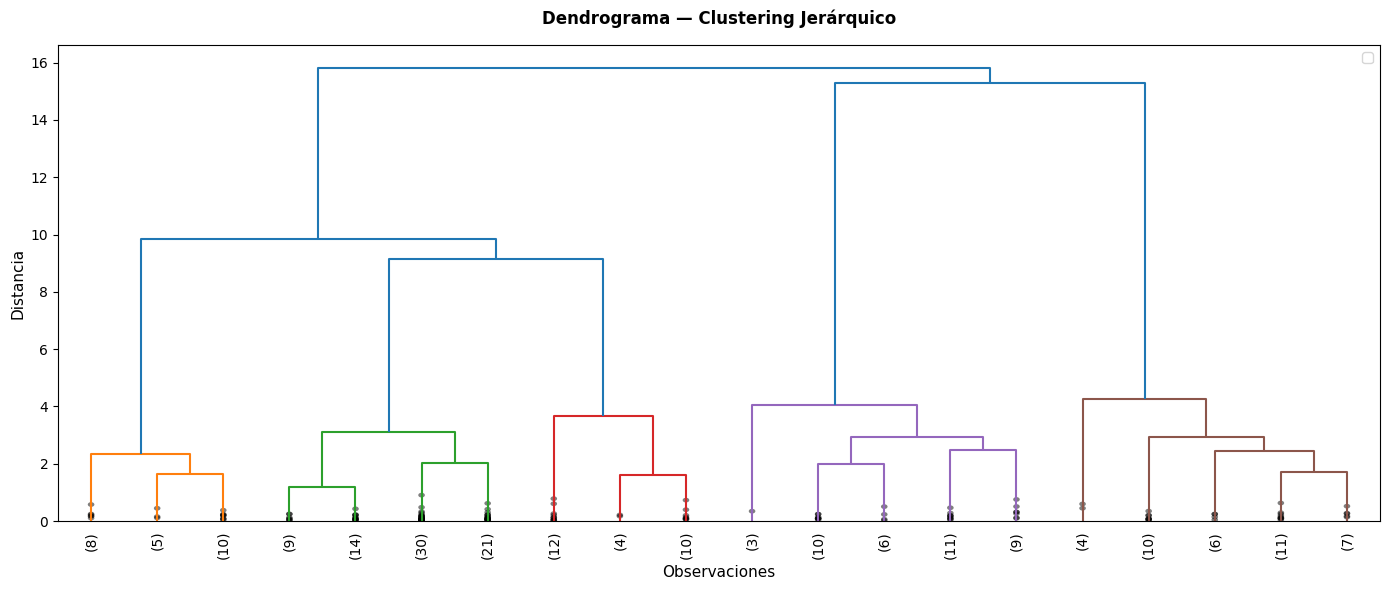

In [13]:
# Calculamos la matriz de distancias euclidianas
dist_matrix = pdist(X_scaled, metric='euclidean')

# Construimos el dendrograma usando enlace Ward
Z = linkage(dist_matrix, method='ward')

#Graficamos el dendograma
fig, ax = plt.subplots(figsize=(14, 6))

d = dendrogram(Z, ax=ax,truncate_mode='lastp', p=20,
    leaf_rotation=90, leaf_font_size=10,
    show_contracted=True, color_threshold=5,
)

ax.set_title('Dendrograma — Clustering Jerárquico',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Observaciones', fontsize=11)
ax.set_ylabel('Distancia', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('dendrograma_ward.png', dpi=150, bbox_inches='tight')
plt.show()

Agrupando las columnas de Ingreso y Puntaje del gasto en un *dataframe*, se aplica la estandarización a los valores para que cada variable tenga media 0 y desviación estándar 1. Una vez estandarizados, se calcula la matriz de distancias euclidianas entre todos los pares de observaciones y se construye la jerarquía. El dendograma, se muestra en el eje Y la distancia a la que se van uniendo los clusters.

El clusterin por jerarquías está basado en distancias por lo que si el Ingreso está expresado en millones y el puntaje de gasto es una escala, la variable de mayor magnitud es la que va a dominar el cálculo de la distancia euclidiana. Es por esto que al estandarizar ambas variables la diferencia entre dos personas con ingresos muy distintos van a tener el mismo peso que una diferencia equivalente en el puntaje de gasto. Es decir que sin estandarización, los clusters reflejarían la variable con mayor escala, generando resultados inestables cuando hay cambio de unidades.

#### 3.2. Número de clusters

Retenga el número de clusters que se obtengan luego de fijar la distancia en 6.

Número de clusters con distancia de corte 6: 5
Cluster
1    23
2    74
3    26
4    39
5    38
Name: count, dtype: int64


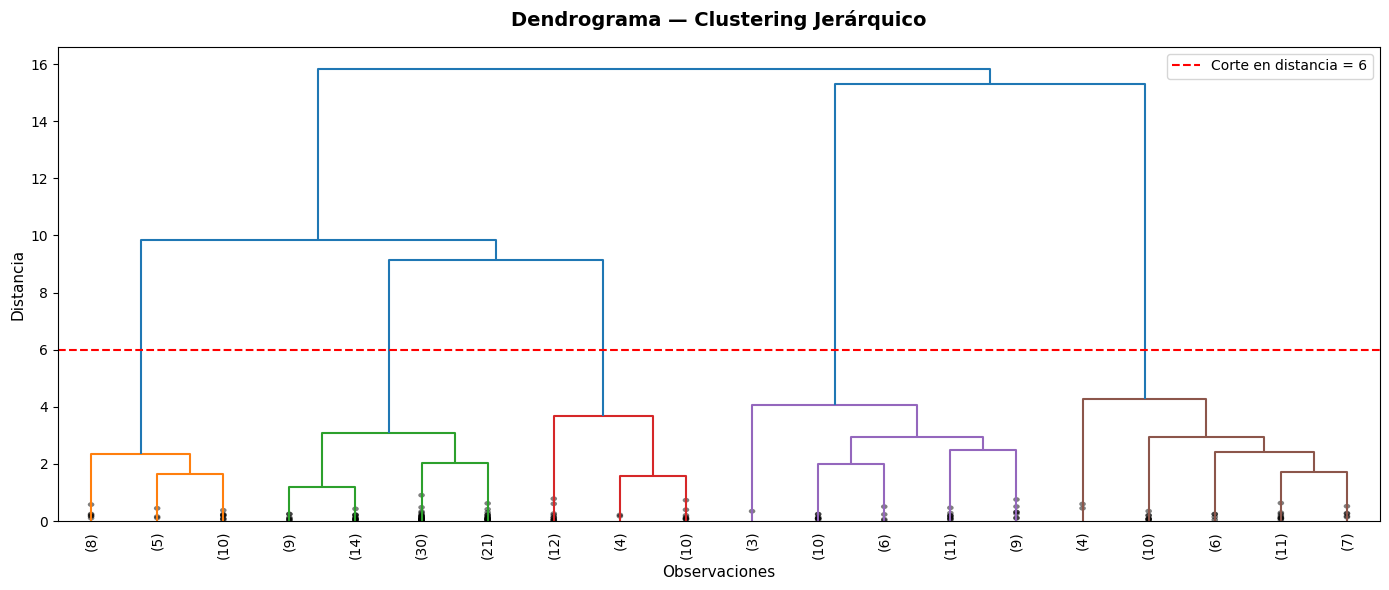

In [14]:
# Cortar el árbol con distancia umbral = 6
labels = fcluster(Z, t=6, criterion='distance')

# Ver cuántos clusters se formaron
k = len(np.unique(labels))
print(f'Número de clusters con distancia de corte 6: {k}')

# Asignar al dataframe original
data['Cluster'] = labels
print(data['Cluster'].value_counts().sort_index())

#Graficamos
fig, ax = plt.subplots(figsize=(14, 6))

d2 = dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
    leaf_rotation=90, leaf_font_size=10, show_contracted=True,
    color_threshold=6,
)

ax.set_title('Dendrograma — Clustering Jerárquico',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Observaciones', fontsize=11)
ax.set_ylabel('Distancia', fontsize=11)

# Línea horizontal en la distancia 6
ax.axhline(y=6, color='red', linestyle='--', linewidth=1.5,
           label='Corte en distancia = 6')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('dendrograma_corte6.png', dpi=150, bbox_inches='tight')
plt.show()

Para fijar el número de clusters óptimo en el clustering jerárquico, se fija una distancia de 6 sobre el dendograma usando el método de enlace Ward y la distancia euclidiana. Al trazar la línea en el umbral, se identificaron 5 clusters, resultado que coincide con el obtenido anteriormente.

Esto debido a que en el clustering jerárquico, el número de grupos solo varía cuando la línea de corte cruza con un nodo de fusión por lo tanto, la partición que se obtiene es estable y consistente con la estructura jerárquica de los datos.



#### 3.3. Algoritmo Jerárquico Aglomerativo

Utilizando el número de clusters encontrados en el paso anterior, aplique el algoritmo jerárquico aglomerativo, utilizando el enlace 'ward' y la distancia euclidiana. Describa los grupos encontrados, en que grupo o grupos concentraría su estrategia de marketing y por qué?

          Ingreso  Puntaje_Gasto
Cluster                         
1        87055.07          18.63
2        28274.67          23.31
3        86537.50          82.13
4        26230.42          78.57
5        55451.26          50.22


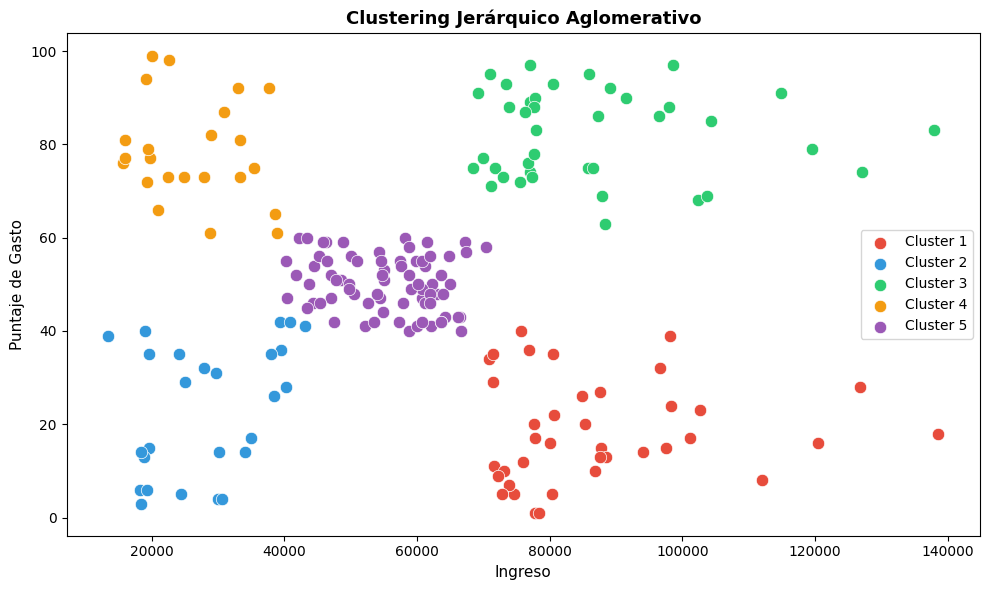

In [15]:
# Aplicar clustering jerárquico aglomerativo
modelo = AgglomerativeClustering(n_clusters=5, linkage='ward', metric='euclidean')

data['Cluster'] = modelo.fit_predict(X_scaled) + 1

# Descripción de los grupos con variables originales (sin estandarizar)
descripcion = data.groupby('Cluster')[['Ingreso', 'Puntaje_Gasto']].mean().round(2)
print(descripcion)

# Visualizar los clusters
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

for i, cluster in enumerate(sorted(data['Cluster'].unique())):
    subset = data[data['Cluster'] == cluster]
    ax.scatter(subset['Ingreso'], subset['Puntaje_Gasto'],
               c=colors[i], label=f'Cluster {cluster}',
               s=80, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Ingreso', fontsize=11)
ax.set_ylabel('Puntaje de Gasto', fontsize=11)
ax.set_title('Clustering Jerárquico Aglomerativo',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Al analizar los resultados del clustering jerárquico aglomerativo con 5 grupos, se identificaron perfiles claramente diferenciados entre los clientes de la tienda. El Cluster 1 agrupa clientes con ingresos altos pero una frecuencia de compra muy baja, lo que sugiere que a pesar de tener capacidad económica, la oferta actual no logra captarlos efectivamente. El Cluster 2 concentra clientes con ingresos bajos y poca frecuencia de compra, representando el segmento de menor potencial de retorno para la tienda. El Cluster 3 corresponde a los clientes más valiosos, combinando ingresos altos con una frecuencia de compra elevada, lo que los convierte en el perfil ideal para cualquier estrategia de marketing. El Cluster 4, aunque presenta ingresos bajos, muestra una frecuencia de compra alta, evidenciando una fuerte lealtad y preferencia por la tienda. Finalmente, el Cluster 5 agrupa al segmento más numeroso, con ingresos y frecuencia de compra medios, representando el comportamiento típico del cliente promedio.

En términos de estrategia de marketing, los esfuerzos deben concentrarse principalmente en los Clusters 3 y 4. El Cluster 3 debe ser el foco central de fidelización, dado que combina alto ingreso con alta frecuencia de compra, por lo que programas con beneficios exclusivos y experiencias personalizadas pueden ser más atractivos para este tipo de clientes. El Cluster 4, por su parte, representa el mayor potencial de crecimiento pues su alta frecuencia de compra a pesar de sus ingresos limitados demuestra una lealtad genuina que puede potenciarse mediante programas de puntos,  promociones o facilidades de pago que incrementen su ticket promedio. Adicionalmente, el Cluster 1 merece una estrategia de activación secundaria, ya que su capacidad económica sin explotar representa una oportunidad concreta de convertirlos en clientes de alto valor.

### 4. DBSCAN

Implemente DBSCAN, al igual que el punto anterior sólo dos variables: su ingreso y el puntaje de gastos. Al implementar  justifique su elección de `min_samples` y `eps`. ¿Cuántos grupos o clusters encuentra? ¿Cuáles son su características? ¿Cambiaría su estrategia de marketing respecto al punto anterior? Justifique su respuesta.

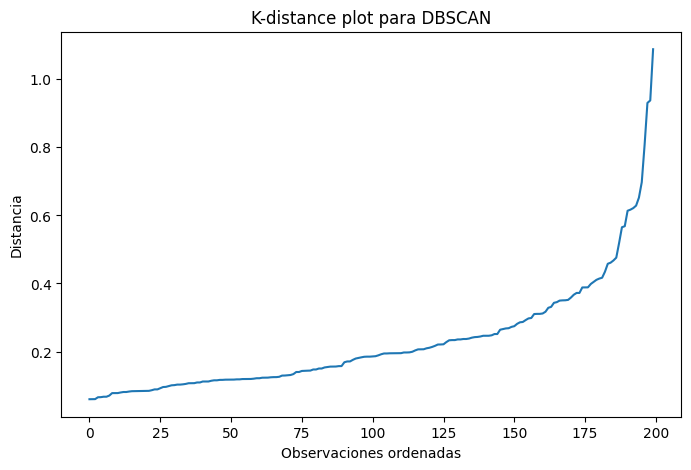

eps sugerido: 0.4110454716793754

Clusters encontrados:
Cluster_DBSCAN
 0    154
 1     33
-1     13
Name: count, dtype: int64

Promedios por cluster:
                     Ingreso  Puntaje_Gasto
Cluster_DBSCAN                             
-1              97274.234615      63.461538
 0              53185.877208      42.051948
 1              80899.975152      83.000000


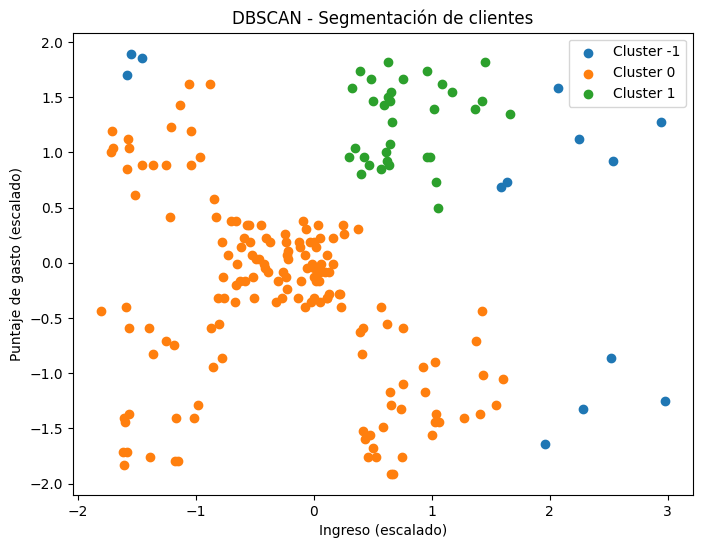

In [16]:
# librerias

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Variables

X = data[['Ingreso', 'Puntaje_Gasto']].copy()

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-DISTANCE (para eps)

k = 4

neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)

distancias, _ = nbrs.kneighbors(X_scaled)

distancias = np.sort(distancias[:, k-1])

# gráfico
plt.figure(figsize=(8,5))
plt.plot(distancias)
plt.title("K-distance plot para DBSCAN")
plt.xlabel("Observaciones ordenadas")
plt.ylabel("Distancia")
plt.show()

# EPS
eps_optimo = np.percentile(distancias, 90)
print("eps sugerido:", eps_optimo)

# DBSCAN
db = DBSCAN(eps=eps_optimo, min_samples=4)
clusters = db.fit_predict(X_scaled)

data['Cluster_DBSCAN'] = clusters

# Resultado

print("\nClusters encontrados:")
print(data['Cluster_DBSCAN'].value_counts())

print("\nPromedios por cluster:")
print(data.groupby('Cluster_DBSCAN')[['Ingreso', 'Puntaje_Gasto']].mean())

# gráfico

plt.figure(figsize=(8,6))

for c in np.unique(clusters):
    subset = X_scaled[clusters == c]
    plt.scatter(subset[:,0], subset[:,1], label=f'Cluster {c}')

plt.title("DBSCAN - Segmentación de clientes")
plt.xlabel("Ingreso (escalado)")
plt.ylabel("Puntaje de gasto (escalado)")
plt.legend()
plt.show()

Se aplicó el algoritmo DBSCAN para la segmentación de clientes utilizando únicamente las variables de ingreso y puntaje de gasto, previamente estandarizadas para garantizar comparabilidad entre escalas. Para la selección del parámetro eps se utilizó el método de k-distancias con k=4, y se obtuvo un valor aproximado de 0.41 a partir del percentil 90 de las distancias ordenadas. Con este valor y un min_samples de 4, el algoritmo identificó tres grupos: un cluster principal (Cluster 0) que concentra la mayoría de clientes con ingresos y niveles de gasto medios, un segundo cluster (Cluster 1) asociado a clientes de altos ingresos y alto gasto, y un conjunto de observaciones clasificadas como ruido (Cluster -1), que corresponden a individuos con comportamientos atípicos respecto a la estructura general de los datos.

### 5. Incorporando más dimensiones

Hasta este momento hemos utilizado solo dos variables para nuestro análisis, sin embargo, la base cuenta con otras variables más: género y edad. Usando las categorías de edad creadas anteriormente incorpore género y grupo etario a su análisis. Genere los grupos utilizando DBSCAN y la distancia de Gower, justificando su elección de `min_samples` y `eps`   ¿Incorporar estas variables, ayuda a la focalización de la estrategia de marketing?

In [17]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir su procedimiento)